In [1]:
!pip install wfdb matplotlib scipy numpy


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Sampling frequency: 360 Hz
Number of samples: 21600
Duration: 60.00 s


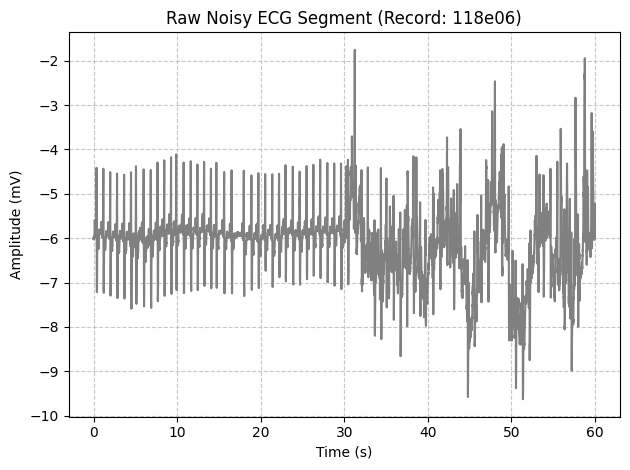

In [ ]:
import wfdb
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import butter, sosfiltfilt

# Load the data from PhysioNet
# 118e06 has 6dB noise
# Sample rate is 360Hz according to the dataset
# Since the noise is occuring after 5min according to the dataset
# Taking from 4.5min to 5.5min time period into consideration
record = wfdb.rdrecord('118e06', pn_dir='nstdb/1.0.0', sampfrom=97200, sampto=118800)

# Extract the signal and the sampling frequency
ecg_signal = record.p_signal[:, 0]  # First ECG lead/channel
fs = record.fs                      # Sampling frequency (360 Hz)
time = np.arange(len(ecg_signal)) / fs # time array in seconds

print(f"Sampling frequency: {fs} Hz")
print(f"Number of samples: {len(ecg_signal)}")
print(f"Duration: {len(ecg_signal)/fs:.2f} s")

fig, ax = plt.subplots()

ax.plot(time, ecg_signal, color='gray');
ax.set_title(f'Raw Noisy ECG Segment (Record: {record.record_name})')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude (mV)')
ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# Need to calculate thresholds according to the dataset


In [ ]:
# Implement functions to measure properties of the ECG segment

# Bandpass Filter
def bandpass_filter(signal, lowcut, highcut, fs, order=2):
    sos = butter(order, [lowcut, highcut], btype='bandpass', fs=fs, output='sos')
    return sosfiltfilt(sos, signal)

# Signal features related to frequencies
def sinalFeatures(ecg, fs=fs):
    x = np.asarray(ecg, dtype=float)

    # Remove DC
    x = x - np.mean(x)

    # Signal RMS
    rms = np.sqrt(np.mean(x ** 2))

    # 1. Check if there is no energy in the ECG band, if there is not it should be an electrode is disconnected
    ecg_band = bandpass_filter(ecg, 0.5, 100)
    ecg_energy = np.mean(ecg_band ** 2)

    # 2. Check for too much baseline wander (Could be an electrode is connected)
    baseline_band = bandpass_filter(ecg, 0.05, 0.5, fs)
    baseline_energy = np.mean(baseline_band ** 2)
    baseline_ratio = baseline_energy / (ecg_energy + 1e-12)

    # 3. Check for power line noise (50Hz and 60Hz)
    powerline50_band = bandpass_filter(ecg, 48, 52, fs)
    powerline60_band = bandpass_filter(ecg, 58, 62, fs)
    powerline_energy = max(np.mean(powerline50_band ** 2), np.mean(powerline60_band ** 2))
    powerline_ratio = powerline_energy / (ecg_energy + 1e-12)

    # 4. Check for muscle tremor
    # ECG - 0.5Hz - 30Hz (mostly)
    # HF noise - 30Hz - 45Hz
    highfreq_band = bandpass_filter(ecg, 0.5, 30, fs)
    lowfreq_band = bandpass_filter(ecg, 30, 45, fs)
    highfreq_ratio = highfreq_band / (lowfreq_band + 1e-12)

    return rms, baseline_ratio, powerline_ratio, highfreq_ratio



In [4]:
# Implement a function to calculate the overall score for the ECG segment

In [ ]:
# Get 5s ECG segments 

In [ ]:
# Depending on the score discard the segment or save the segment


axes[1].plot(time, filtered_signal, color='red')
axes[1].set_title('Denoised ECG (0.5 - 45 Hz Butterworth Bandpass Filter)')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Amplitude (mV)')
axes[1].grid(True, linestyle='--', alpha=0.7)